In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings

# Uyarıları gizle
warnings.filterwarnings('ignore')

# Grafik stili
plt.style.use('ggplot')


In [2]:
# Veriyi yükleyin
df = pd.read_csv('../dataset/train.csv')

# Veri setinin ilk birkaç satırını inceleyin
df.head()


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [3]:
# Özellik mühendisliği
df['engine_power'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df['engine_volume'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
df['cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)
df['fuel_type'] = df['fuel_type'].str.replace('Gasoline/Mild Electric Hybrid', 'Hybrid')
df['fuel_type'] = df['fuel_type'].str.replace('Plug-In Electric/Gas', 'Hybrid')
df['fuel_type'] = df['fuel_type'].str.replace('Gas/Electric Hybrid', 'Hybrid')
df['age'] = 2023 - df['model_year']
df['accident'] = df['accident'].apply(lambda x: 1 if 'accident' in str(x) else 0)
df['clean_title'] = df['clean_title'].apply(lambda x: 1 if str(x) == 'Yes' else 0)
df['transmission_type'] = df['transmission'].apply(
    lambda x: 'Automatic' if 'A/T' in str(x) else 'Manual' if 'M/T' in str(x) else 'Other')

# Temizlik işlemleri
df = df.dropna(subset=['engine_power', 'engine_volume', 'cylinders'])
df['clean_title'].fillna(0, inplace=True)

# Veri setinin son halini inceleyin
df.head()


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_power,engine_volume,cylinders,age,transmission_type
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,0,1,4200,172.0,1.6,4.0,16,Automatic
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,1,1,4999,252.0,3.9,8.0,21,Automatic
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,0,1,13900,320.0,5.3,8.0,21,Automatic
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,0,1,45000,420.0,5.0,8.0,6,Other
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,0,1,97500,208.0,2.0,4.0,2,Automatic


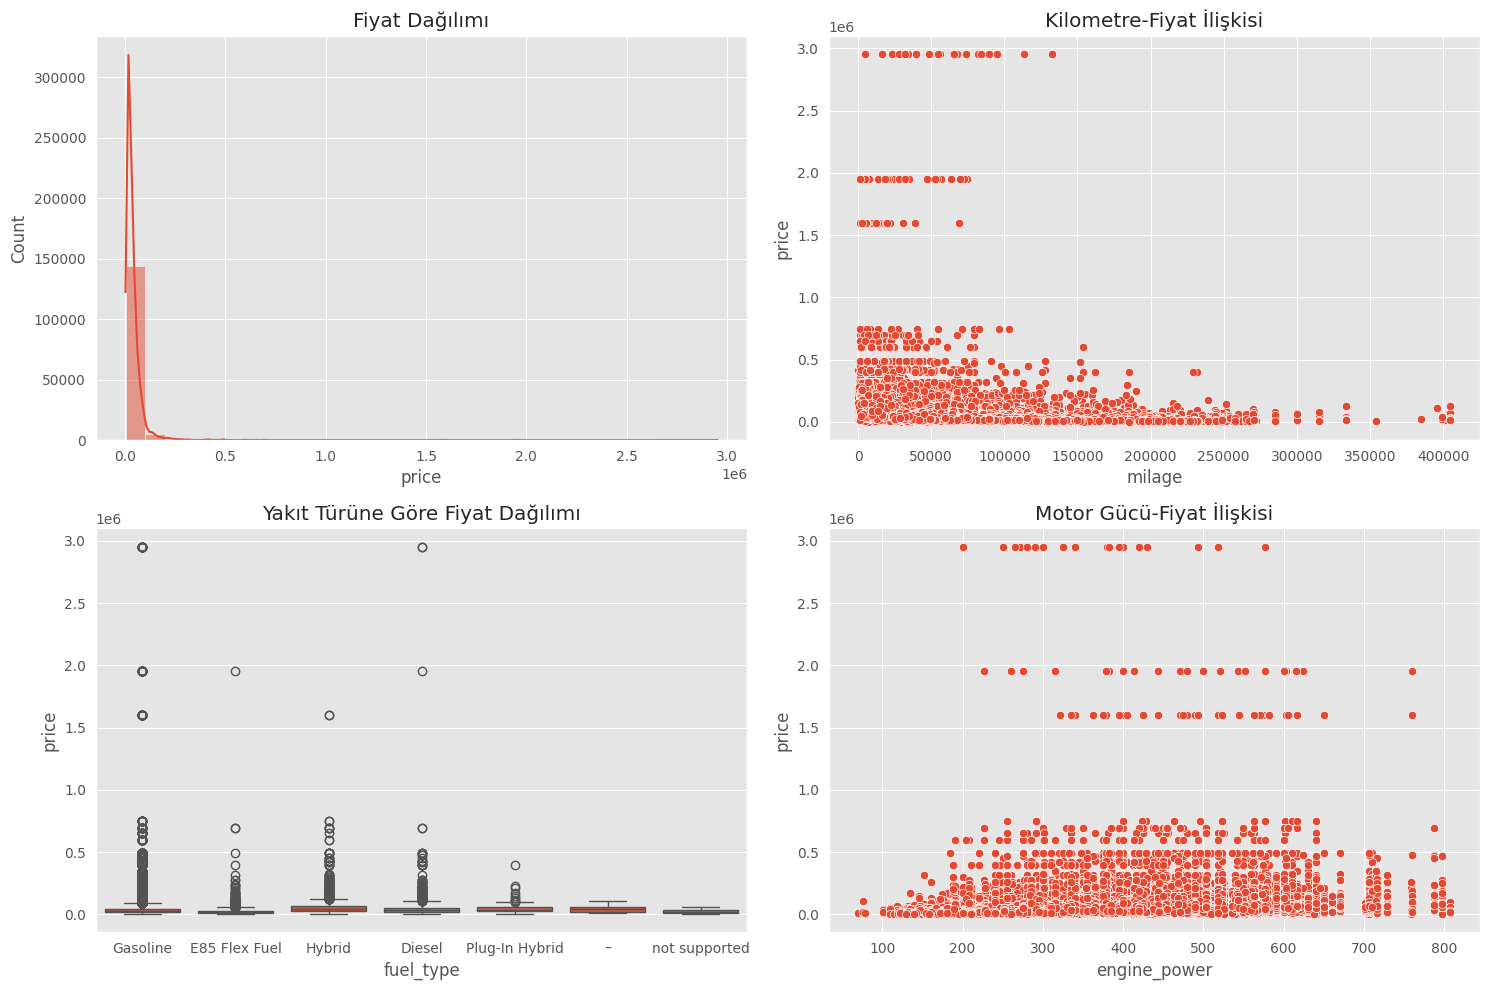

In [4]:
# Veri dağılımı görselleştirmeleri
plt.figure(figsize=(15, 10))

# Fiyat dağılımı
plt.subplot(2, 2, 1)
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Fiyat Dağılımı')

# Kilometre ve Fiyat İlişkisi
plt.subplot(2, 2, 2)
sns.scatterplot(x='milage', y='price', data=df)
plt.title('Kilometre-Fiyat İlişkisi')

# Yakıt Türüne Göre Fiyat Dağılımı
plt.subplot(2, 2, 3)
sns.boxplot(x='fuel_type', y='price', data=df)
plt.title('Yakıt Türüne Göre Fiyat Dağılımı')

# Motor Gücü ve Fiyat İlişkisi
plt.subplot(2, 2, 4)
sns.scatterplot(x='engine_power', y='price', data=df)
plt.title('Motor Gücü-Fiyat İlişkisi')

plt.tight_layout()
plt.savefig('data_distribution.png')
plt.show()


In [5]:
# Kategorik ve sayısal sütunları ayırma
categorical_cols = ['brand', 'fuel_type', 'transmission_type']
numerical_cols = ['model_year', 'milage', 'engine_power', 'engine_volume',
                  'cylinders', 'age', 'accident', 'clean_title']

categorical_cols, numerical_cols


(['brand', 'fuel_type', 'transmission_type'],
 ['model_year',
  'milage',
  'engine_power',
  'engine_volume',
  'cylinders',
  'age',
  'accident',
  'clean_title'])

In [6]:
# Kolon ön işleme
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Model pipeline oluşturma
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Modeli eğitmek için veriyi hazırlama
X = df[numerical_cols + categorical_cols]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
# Modeli eğitme
print("Model eğitiliyor...")
model.fit(X_train, y_train)

Model eğitiliyor...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['model_year', 'milage',
                                                   'engine_power',
                                                   'engine_volume', 'cylinders',
                                                   'age', 'accident',
                                                   'clean_title']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission_type'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

In [8]:
# Tahminler
y_pred = model.predict(X_test)

# Model değerlendirme metrikleri
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mae, mse, rmse, r2


(16053.430615944388,
 2747230558.333646,
 np.float64(52414.030166870834),
 0.19083024846998753)

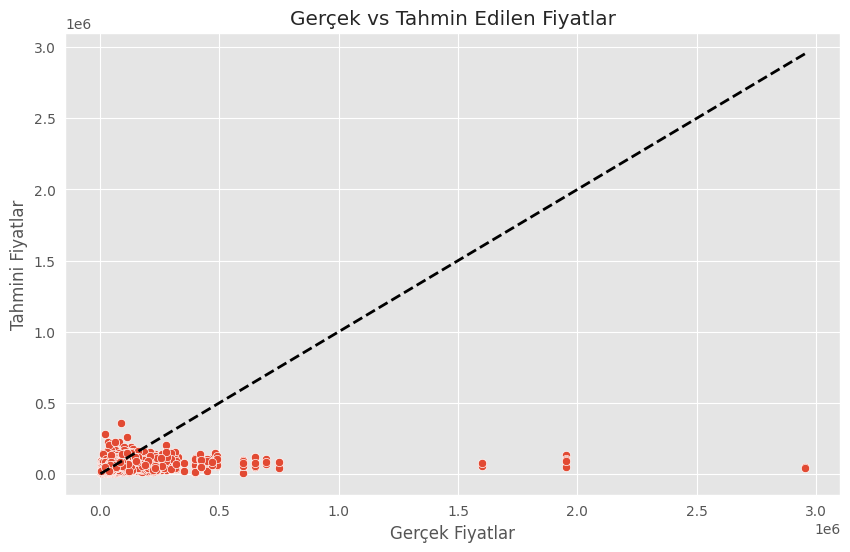

In [9]:
# Gerçek vs Tahmin Grafiği
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Gerçek Fiyatlar')
plt.ylabel('Tahmini Fiyatlar')
plt.title('Gerçek vs Tahmin Edilen Fiyatlar')
plt.savefig('actual_vs_predicted.png')
plt.show()


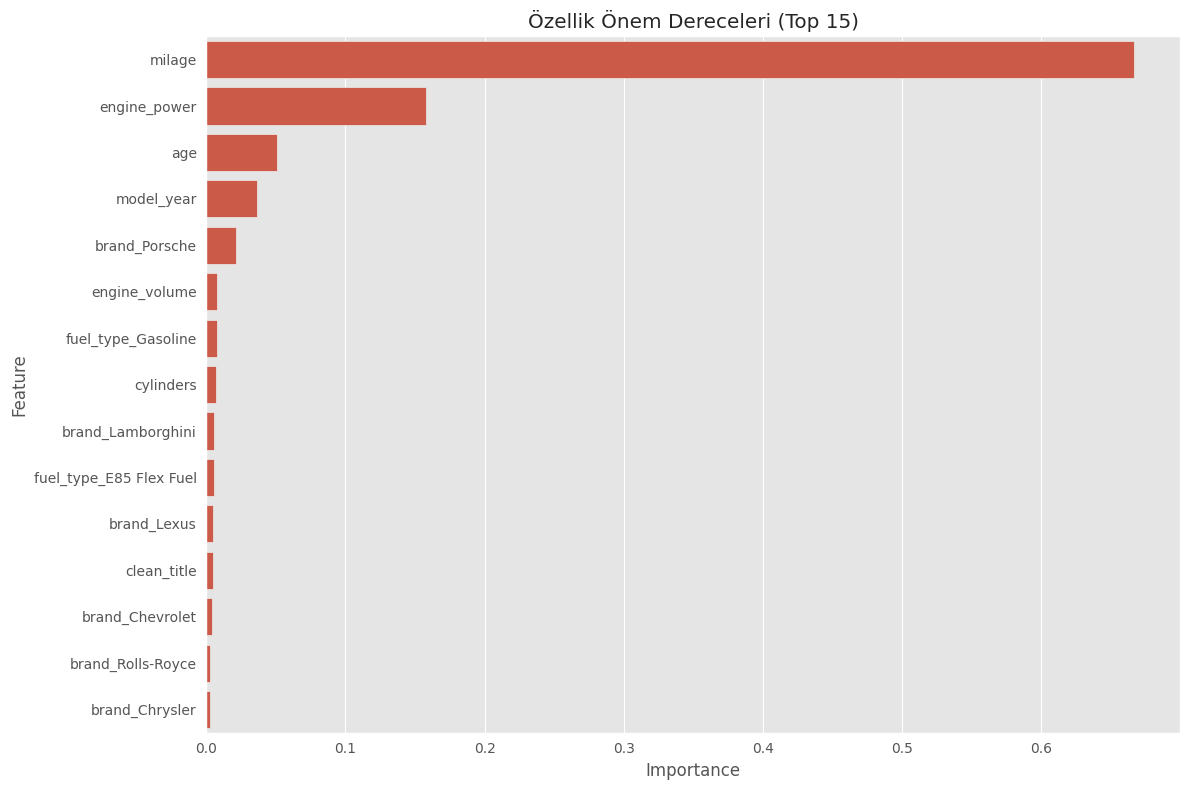

In [10]:
# Özellik önem derecelerini görselleştirme
try:
    feature_importances = model.named_steps['regressor'].feature_importances_
    cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
    cat_features = cat_encoder.get_feature_names_out(categorical_cols)
    all_features = numerical_cols + list(cat_features)

    importance_df = pd.DataFrame({'Feature': all_features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Özellik Önem Dereceleri (Top 15)')
    plt.tight_layout()
    plt.savefig('feature_importances.png')
    plt.show()
except Exception as e:
    print(f"\nÖzellik önem dereceleri çizilemedi: {str(e)}")


In [11]:
# Kullanıcıdan veri alma fonksiyonu
def get_user_input():
    print("\n" + "="*50)
    print("Araç Özelliklerini Girin:")
    print("="*50)

    brand = input("\nMarka (Örnek: Toyota, BMW, Ford): ").strip().title()
    model_year = int(input("Model Yılı (Örnek: 2015): "))
    milage = int(input("Kilometre (Örnek: 50000): "))
    fuel_type = input("Yakıt Türü (Gasoline, Diesel, Hybrid, Electric): ").strip().title()
    engine_power = float(input("Motor Gücü (HP) (Örnek: 150): "))
    engine_volume = float(input("Motor Hacmi (L) (Örnek: 2.0): "))
    cylinders = int(input("Silindir Sayısı (Örnek: 4): "))
    transmission_type = input("Şanzıman Türü (Automatic, Manual, Other): ").strip().title()
    accident = input("Kaza Geçmişi Var mı? (Evet/Hayır): ").lower() == 'evet'
    clean_title = input("Temiz Başlık? (Evet/Hayır): ").lower() == 'evet'

    # Yaş hesapla
    current_year = pd.Timestamp.now().year
    age = current_year - model_year

    # Veri sözlüğü oluştur
    input_data = {
        'brand': [brand],
        'model_year': [model_year],
        'milage': [milage],
        'fuel_type': [fuel_type],
        'engine_power': [engine_power],
        'engine_volume': [engine_volume],
        'cylinders': [cylinders],
        'transmission_type': [transmission_type],
        'age': [age],
        'accident': [1 if accident else 0],
        'clean_title': [1 if clean_title else 0]
    }

    return pd.DataFrame(input_data)

# Kullanıcıdan giriş al ve tahmin yap
user_data = get_user_input()

# Tahmin yap
predicted_price = model.predict(user_data)[0]

# Sonuçları gösterme
print("\n" + "="*50)
print("TAHMİN SONUÇLARI")
print("="*50)
print(f"\nTahmini Araç Fiyatı: ${predicted_price:,.2f}")



Araç Özelliklerini Girin:


KeyboardInterrupt: Interrupted by user